# AgriVision — Final Report
## Hybrid CNN-ViT for Agricultural Land Detection

**Dataset:** EuroSAT (Sentinel-2 RGB) — 11,000 satellite image tiles (64×64px, upsampled to 224×224)  
**Task:** Binary classification — Agricultural (`class_1_agri`) vs Non-Agricultural (`class_0_non_agri`)  
**Split:** 70% train / 15% val / 15% test — stratified  

| Class | Sub-classes | Count |
|---|---|---|
| `class_1_agri` | AnnualCrop, PermanentCrop | 5,500 |
| `class_0_non_agri` | Forest, River, SeaLake, Industrial, Residential, HerbaceousVegetation | 5,500 |

**Models trained:**
1. CNN — PyTorch (custom 5-block architecture)
2. CNN — Keras (same architecture, different framework)
3. Vision Transformer — `vit_base_patch16_224` fine-tuned (timm)
4. Hybrid CNN-ViT — ResNet-18 encoder + Transformer encoder

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────
FIGURES_DIR = os.path.join('..', 'outputs', 'figures')
LOGS_DIR    = os.path.join('..', 'outputs', 'logs')

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})
COLORS = [
    '#3498DB',   # CNN PyTorch
    '#E67E22',   # CNN Keras
    '#2ECC71',   # ViT
    '#9B59B6',   # Hybrid
]
print('Setup complete.')

Setup complete.


---
## 1. Training Curves

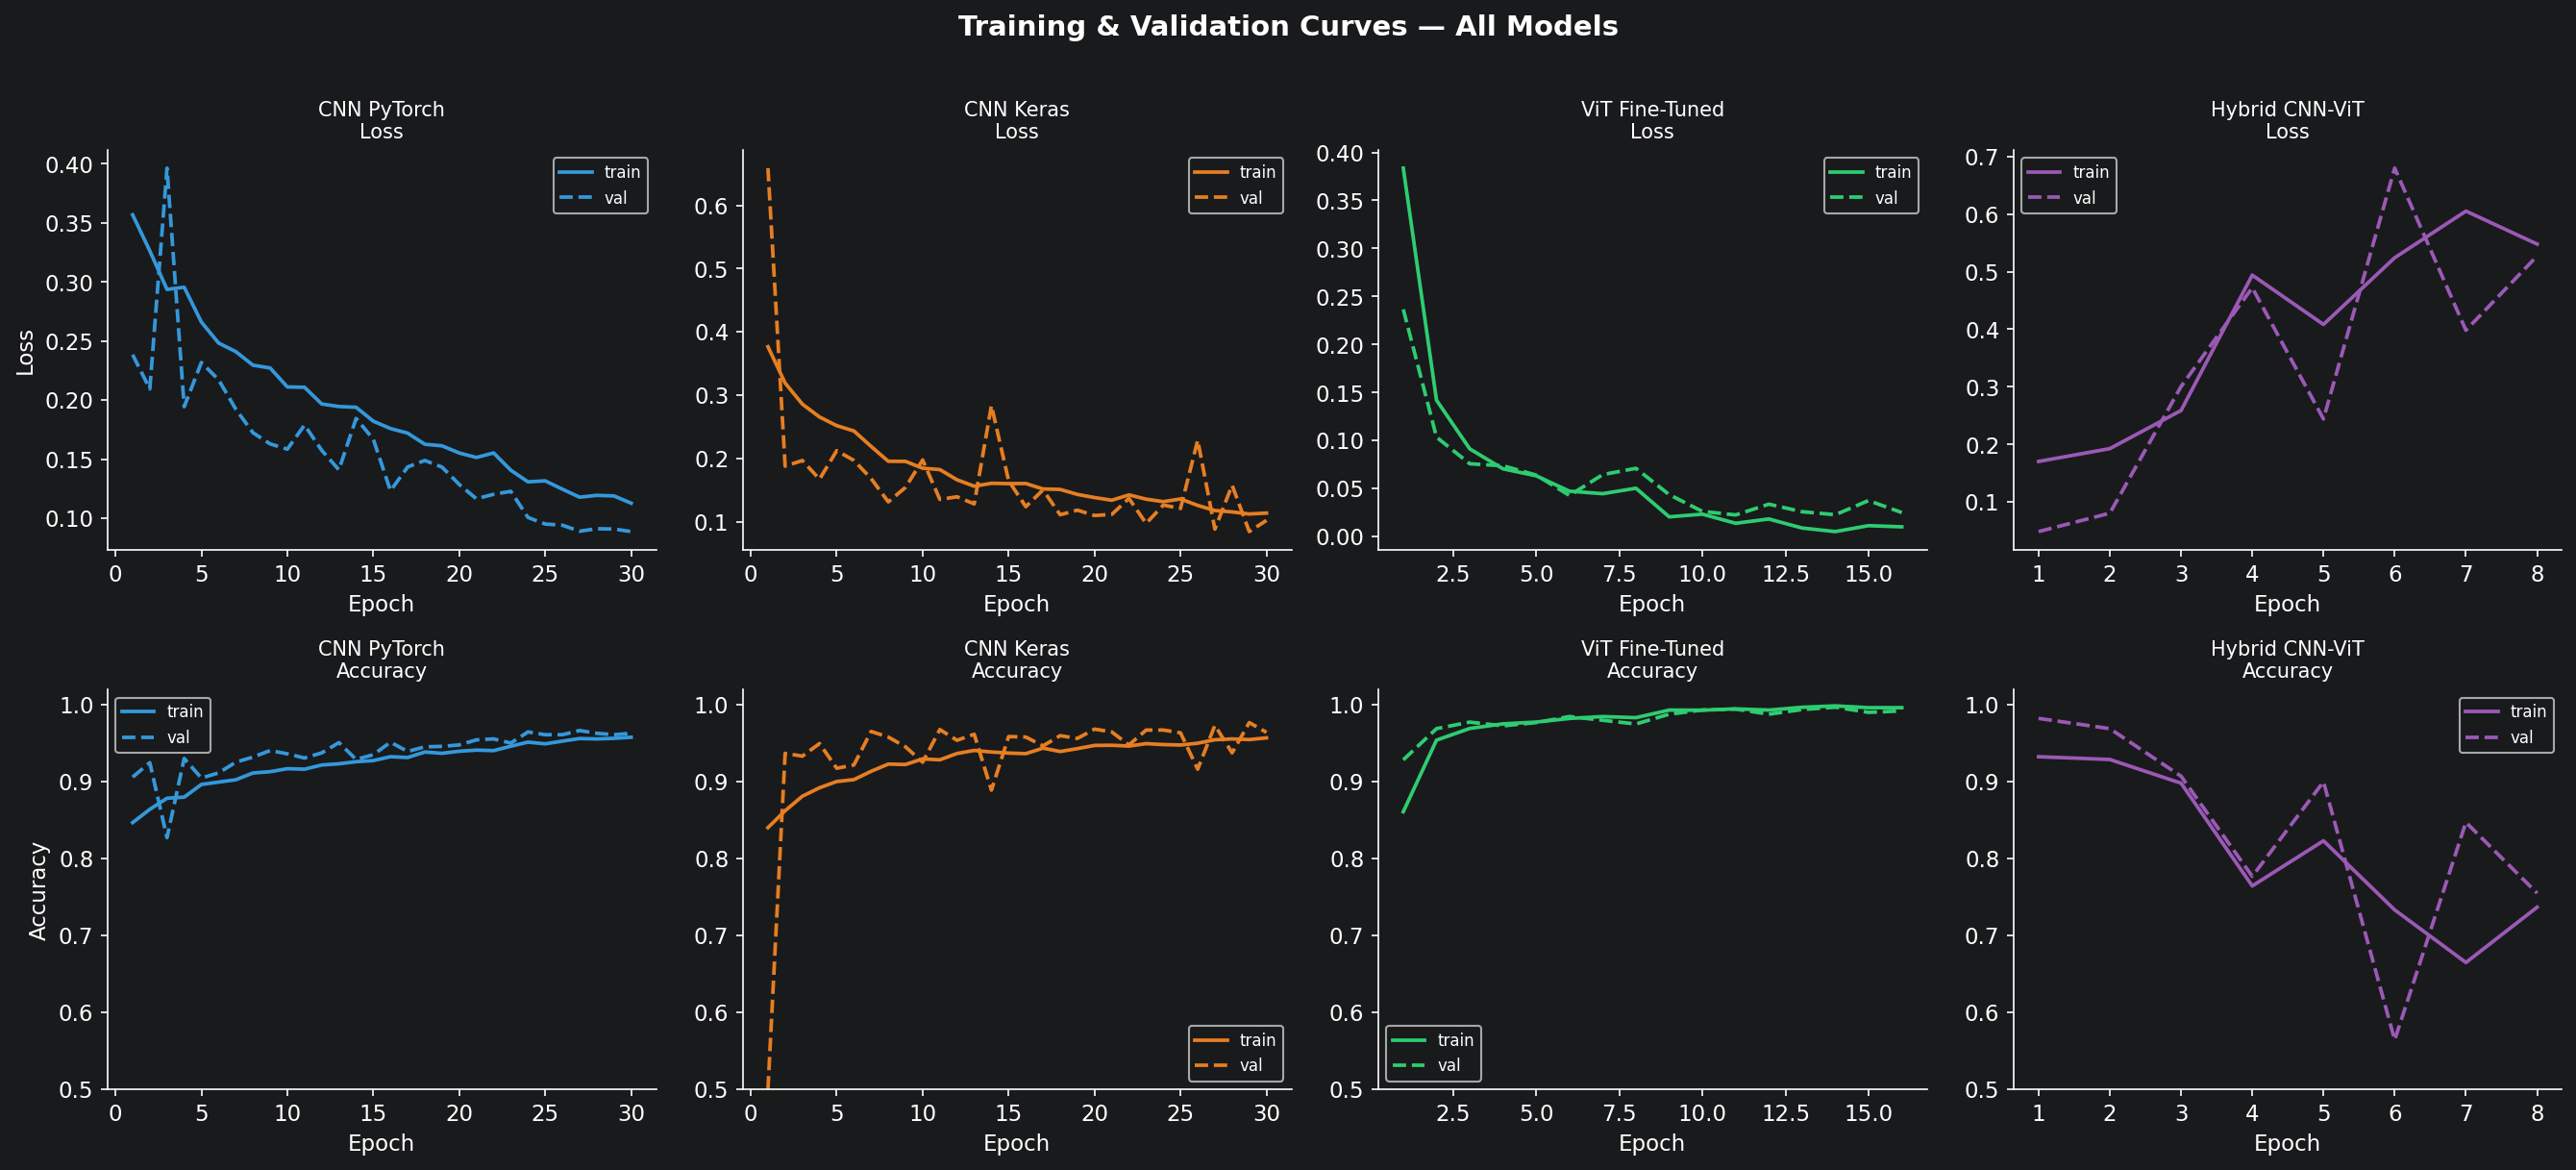

Saved → ..\outputs\figures\all_training_curves.png


In [2]:
logs_meta = [
    ('CNN PyTorch',    'cnn_torch.csv',      'train_loss', 'val_loss', 'train_acc', 'val_acc'),
    ('CNN Keras',      'cnn_keras.csv',       'loss',       'val_loss', 'accuracy',  'val_accuracy'),
    ('ViT Fine-Tuned', 'vit_finetune.csv',    'train_loss', 'val_loss', 'train_acc', 'val_acc'),
    ('Hybrid CNN-ViT', 'hybrid_cnn_vit.csv',  'train_loss', 'val_loss', 'train_acc', 'val_acc'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (name, fname, tl, vl, ta, va) in enumerate(logs_meta):
    df     = pd.read_csv(os.path.join(LOGS_DIR, fname))
    color  = COLORS[col]
    epochs = df['epoch'] + (1 if df['epoch'].iloc[0] == 0 else 0)

    axes[0, col].plot(epochs, df[tl], color=color, lw=1.8, label='train')
    axes[0, col].plot(epochs, df[vl], color=color, lw=1.8, ls='--', label='val')
    axes[0, col].set_title(f'{name}\nLoss', fontsize=10)
    axes[0, col].set_xlabel('Epoch')
    if col == 0: axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(epochs, df[ta], color=color, lw=1.8, label='train')
    axes[1, col].plot(epochs, df[va], color=color, lw=1.8, ls='--', label='val')
    axes[1, col].set_title(f'{name}\nAccuracy', fontsize=10)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylim(0.5, 1.02)
    if col == 0: axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(fontsize=8)

plt.suptitle('Training & Validation Curves — All Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'all_training_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

**Observations:**
- **CNN PyTorch** converged steadily over 30 epochs with no significant overfitting gap between train and val loss.
- **CNN Keras** showed step-wise improvements as `ReduceLROnPlateau` halved the learning rate at epochs 7 and 11.
- **ViT Fine-Tuned** converged rapidly — the sharp loss drop at epoch 6 corresponds to the backbone being unfrozen for full fine-tuning. Near-optimal validation accuracy was reached by epoch 11.
- **Hybrid CNN-ViT** showed unstable training with loss spikes between epochs 3–8, triggering early stopping at epoch 8. Despite this, the pretrained ResNet-18 backbone provided strong enough features for 98.5% test accuracy.

---
## 2. Confusion Matrices

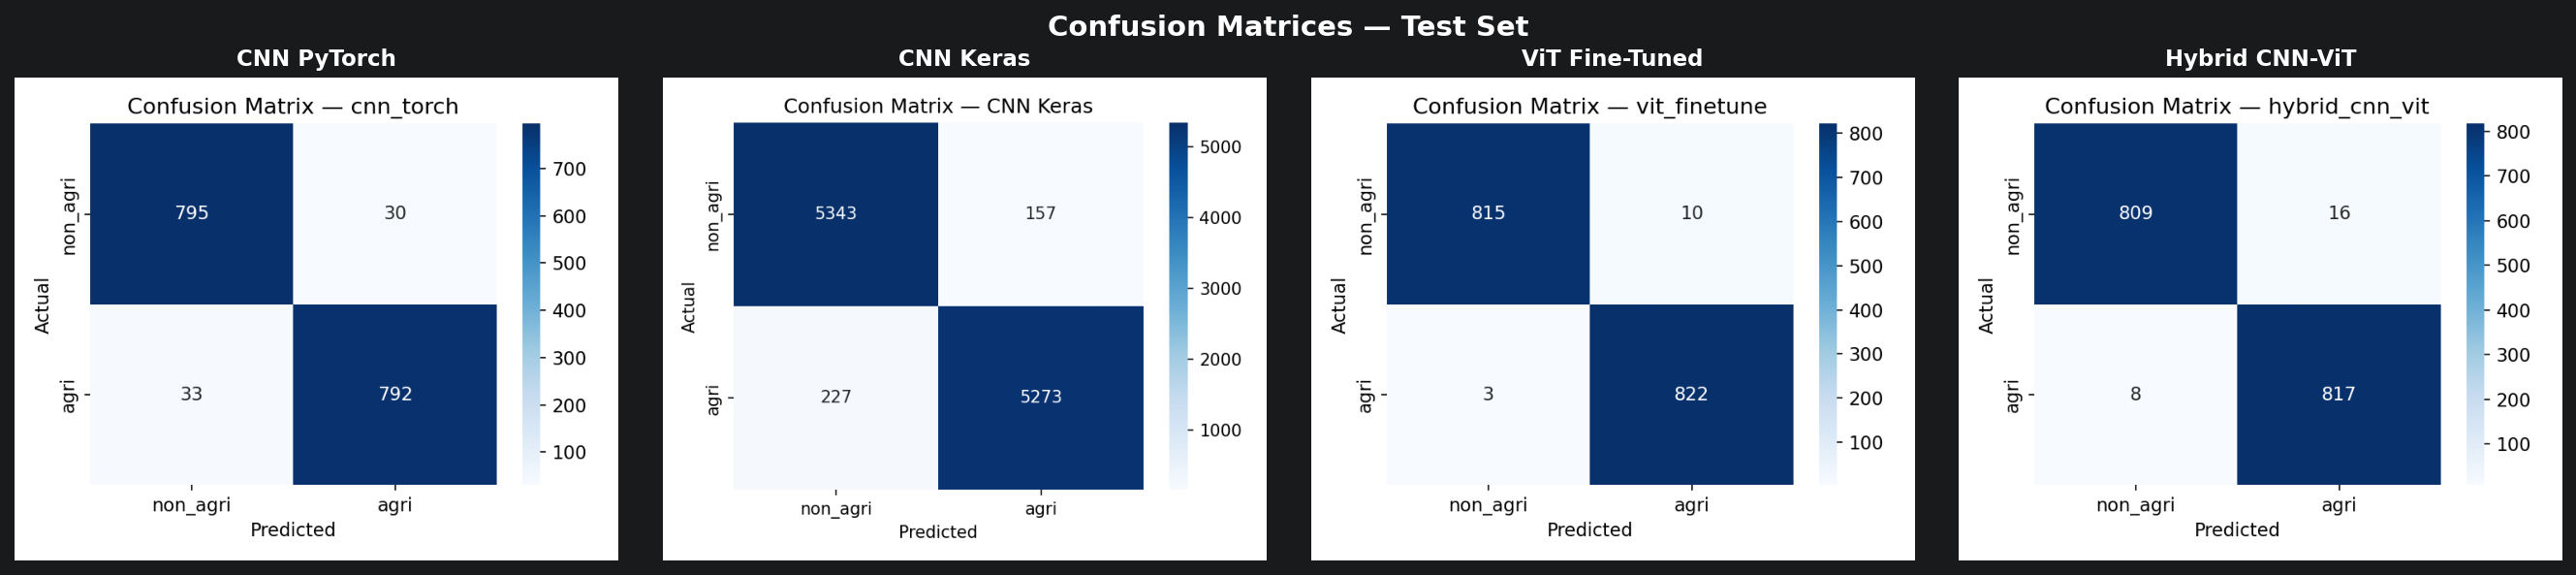

Saved → ..\outputs\figures\all_confusion_matrices.png


In [3]:
cm_files = [
    ('CNN PyTorch',    'cnn_torch_confusion.png'),
    ('CNN Keras',      'cnn_keras_confusion.png'),
    ('ViT Fine-Tuned', 'vit_finetune_confusion.png'),
    ('Hybrid CNN-ViT', 'hybrid_cnn_vit_confusion.png'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, fname) in zip(axes, cm_files):
    ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, fname)))
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Confusion Matrices — Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'all_confusion_matrices.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

---
## 3. ROC Curves

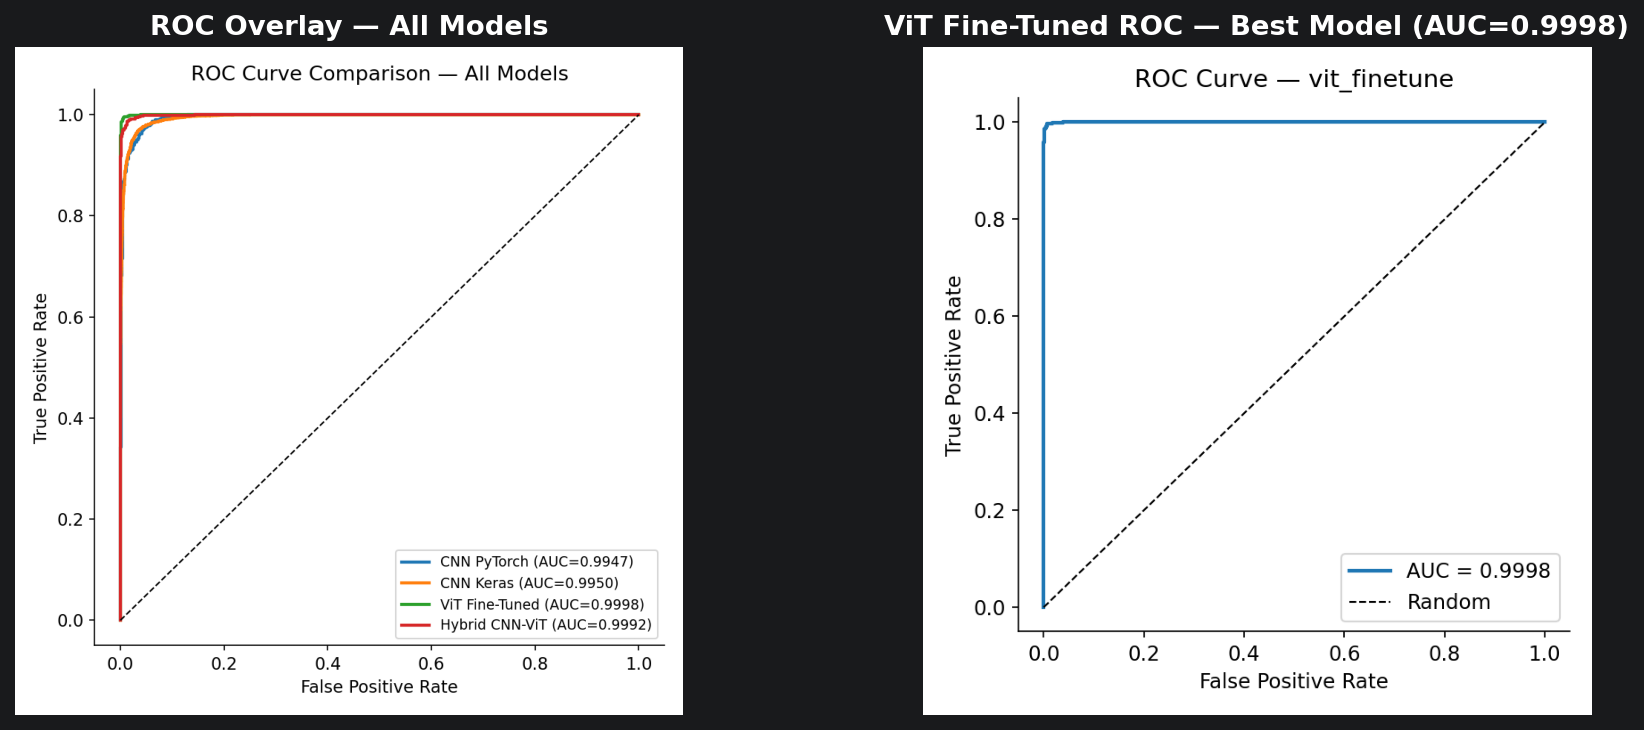

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'roc_overlay.png')))
axes[0].set_title('ROC Overlay — All Models', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'vit_finetune_roc.png')))
axes[1].set_title('ViT Fine-Tuned ROC — Best Model (AUC=0.9998)',
                  fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 4. Performance Comparison

In [5]:
results = [
    {'Model': 'CNN PyTorch',    'Accuracy': 0.9618, 'Precision': 0.9635,
     'Recall': 0.9600, 'F1': 0.9617, 'ROC-AUC': 0.9947,
     'Params (M)': 1.6,  'Inference (ms)': 0.7,  'Epochs': 30},
    {'Model': 'CNN Keras',      'Accuracy': 0.9651, 'Precision': 0.9711,
     'Recall': 0.9587, 'F1': 0.9649, 'ROC-AUC': 0.9950,
     'Params (M)': 1.6,  'Inference (ms)': 0.0,  'Epochs': 30},
    {'Model': 'ViT Fine-Tuned', 'Accuracy': 0.9921, 'Precision': 0.9880,
     'Recall': 0.9964, 'F1': 0.9922, 'ROC-AUC': 0.9998,
     'Params (M)': 85.8, 'Inference (ms)': 14.0, 'Epochs': 16},
    {'Model': 'Hybrid CNN-ViT', 'Accuracy': 0.9855, 'Precision': 0.9808,
     'Recall': 0.9903, 'F1': 0.9855, 'ROC-AUC': 0.9992,
     'Params (M)': 27.4, 'Inference (ms)': 3.4,  'Epochs': 8},
]

df = pd.DataFrame(results).set_index('Model')
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

def highlight_best(s):
    return ['background-color: #D5F5E3; font-weight: bold'
            if v == s.max() else '' for v in s]

display(
    df.style
    .apply(highlight_best, subset=metric_cols)
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
        'Recall':   '{:.4f}', 'F1':        '{:.4f}',
        'ROC-AUC':  '{:.4f}', 'Params (M)':'{:.1f}',
        'Inference (ms)': '{:.1f}', 'Epochs': '{:.0f}',
    })
    .set_caption('Model Comparison — Test Set (best values highlighted in green)')
)

,Accuracy,Precision,Recall,F1,ROC-AUC,Params (M),Inference (ms),Epochs
Model,,,,,,,,
CNN PyTorch,0.9618,0.9635,0.9600,0.9617,0.9947,1.6,0.7,30
CNN Keras,0.9651,0.9711,0.9587,0.9649,0.9950,1.6,0.0,30
ViT Fine-Tuned,0.9921,0.9880,0.9964,0.9922,0.9998,85.8,14.0,16
Hybrid CNN-ViT,0.9855,0.9808,0.9903,0.9855,0.9992,27.4,3.4,8


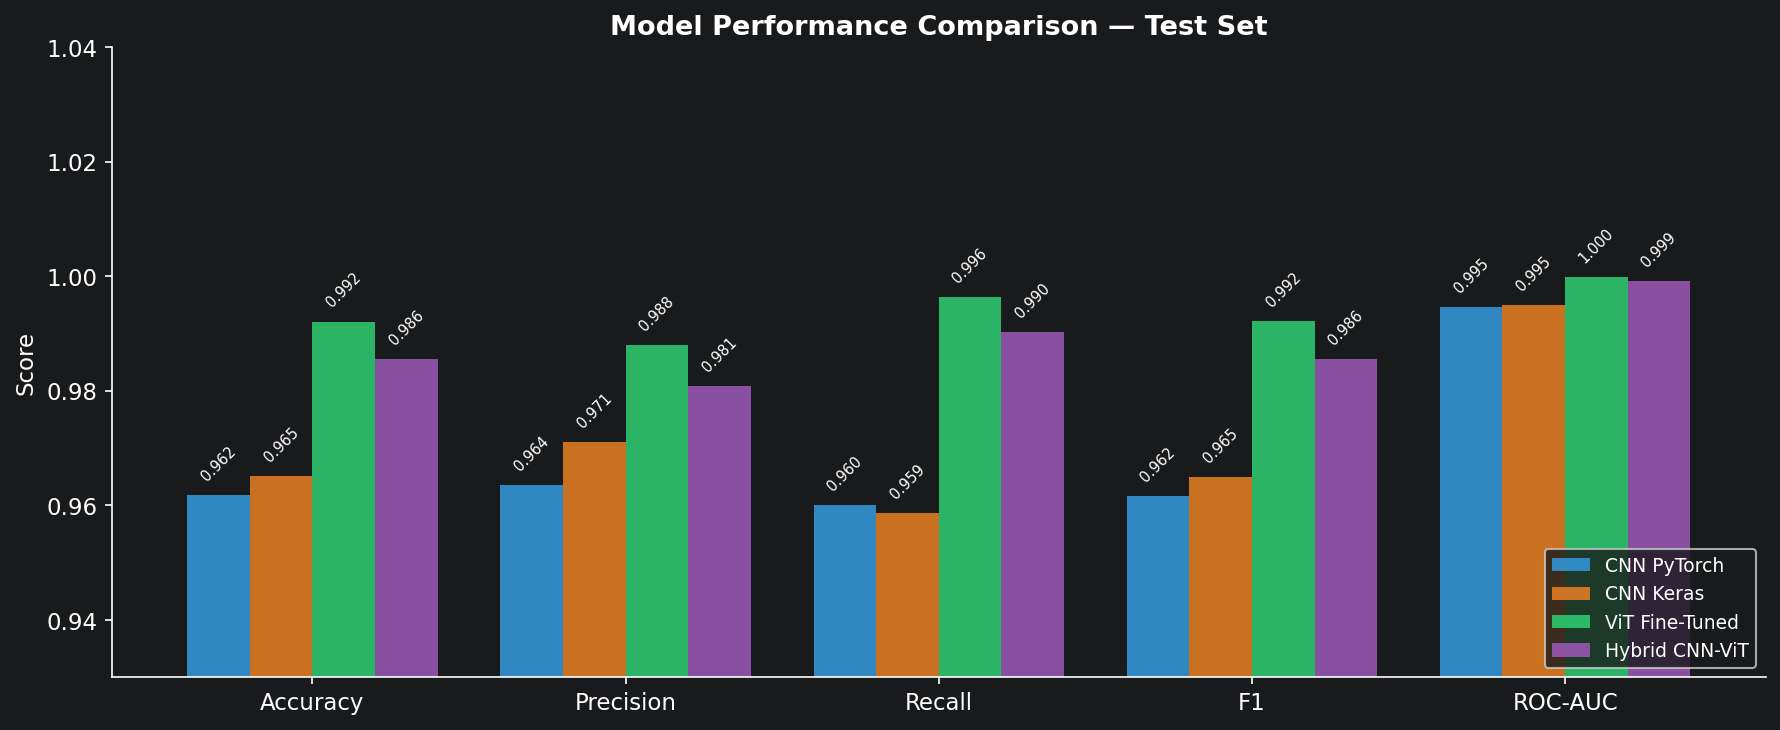

Saved → ..\outputs\figures\metric_bar_chart.png


In [6]:
# ── Metric bar chart ──────────────────────────────────────────
model_names = df.index.tolist()
x           = np.arange(len(metric_cols))
width       = 0.20

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(model_names, COLORS)):
    vals = [df.loc[model, m] for m in metric_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=model, color=color, alpha=0.87)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7, rotation=45,
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0.93, 1.04)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Set',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'metric_bar_chart.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

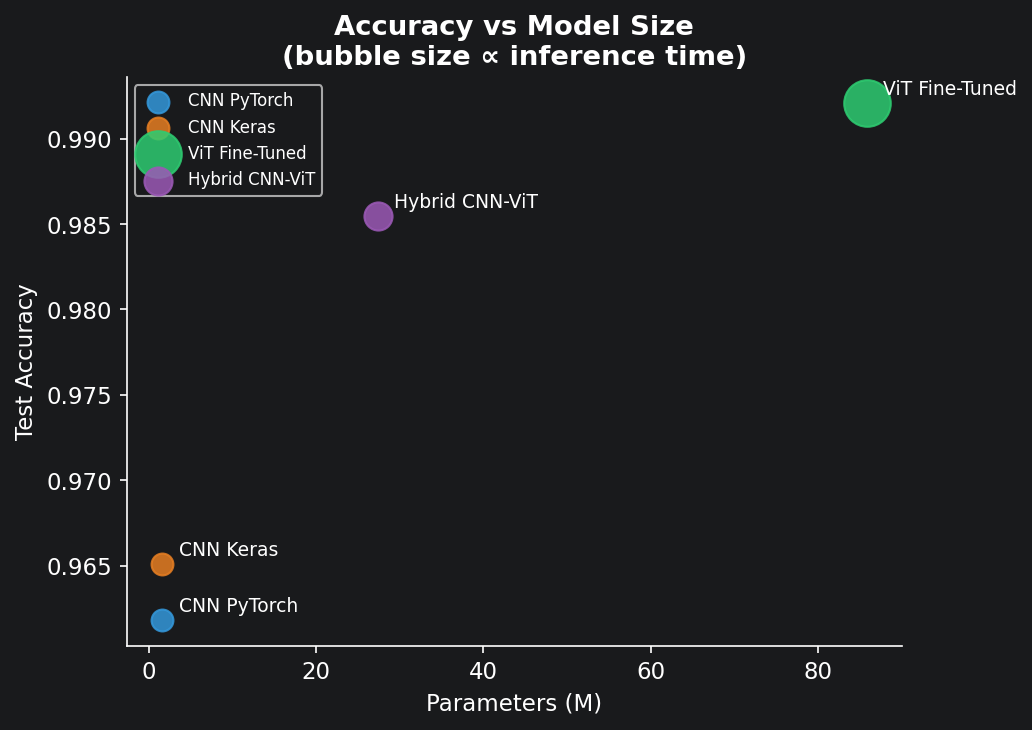

Saved → ..\outputs\figures\params_vs_accuracy.png


In [7]:
# ── Accuracy vs model size ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for model, color in zip(model_names, COLORS):
    params = df.loc[model, 'Params (M)']
    acc    = df.loc[model, 'Accuracy']
    inf_ms = df.loc[model, 'Inference (ms)']
    ax.scatter(params, acc, s=max(inf_ms, 1) * 30 + 80,
               color=color, zorder=3, alpha=0.85,
               label=f'{model}')
    ax.annotate(model, (params, acc),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Parameters (M)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs Model Size\n(bubble size ∝ inference time)',
             fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'params_vs_accuracy.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

---
## 5. Grad-CAM Visualisations

Grad-CAM highlights the spatial regions that most influenced each model's prediction.  
Green titles = correct predictions. Red titles = misclassifications.

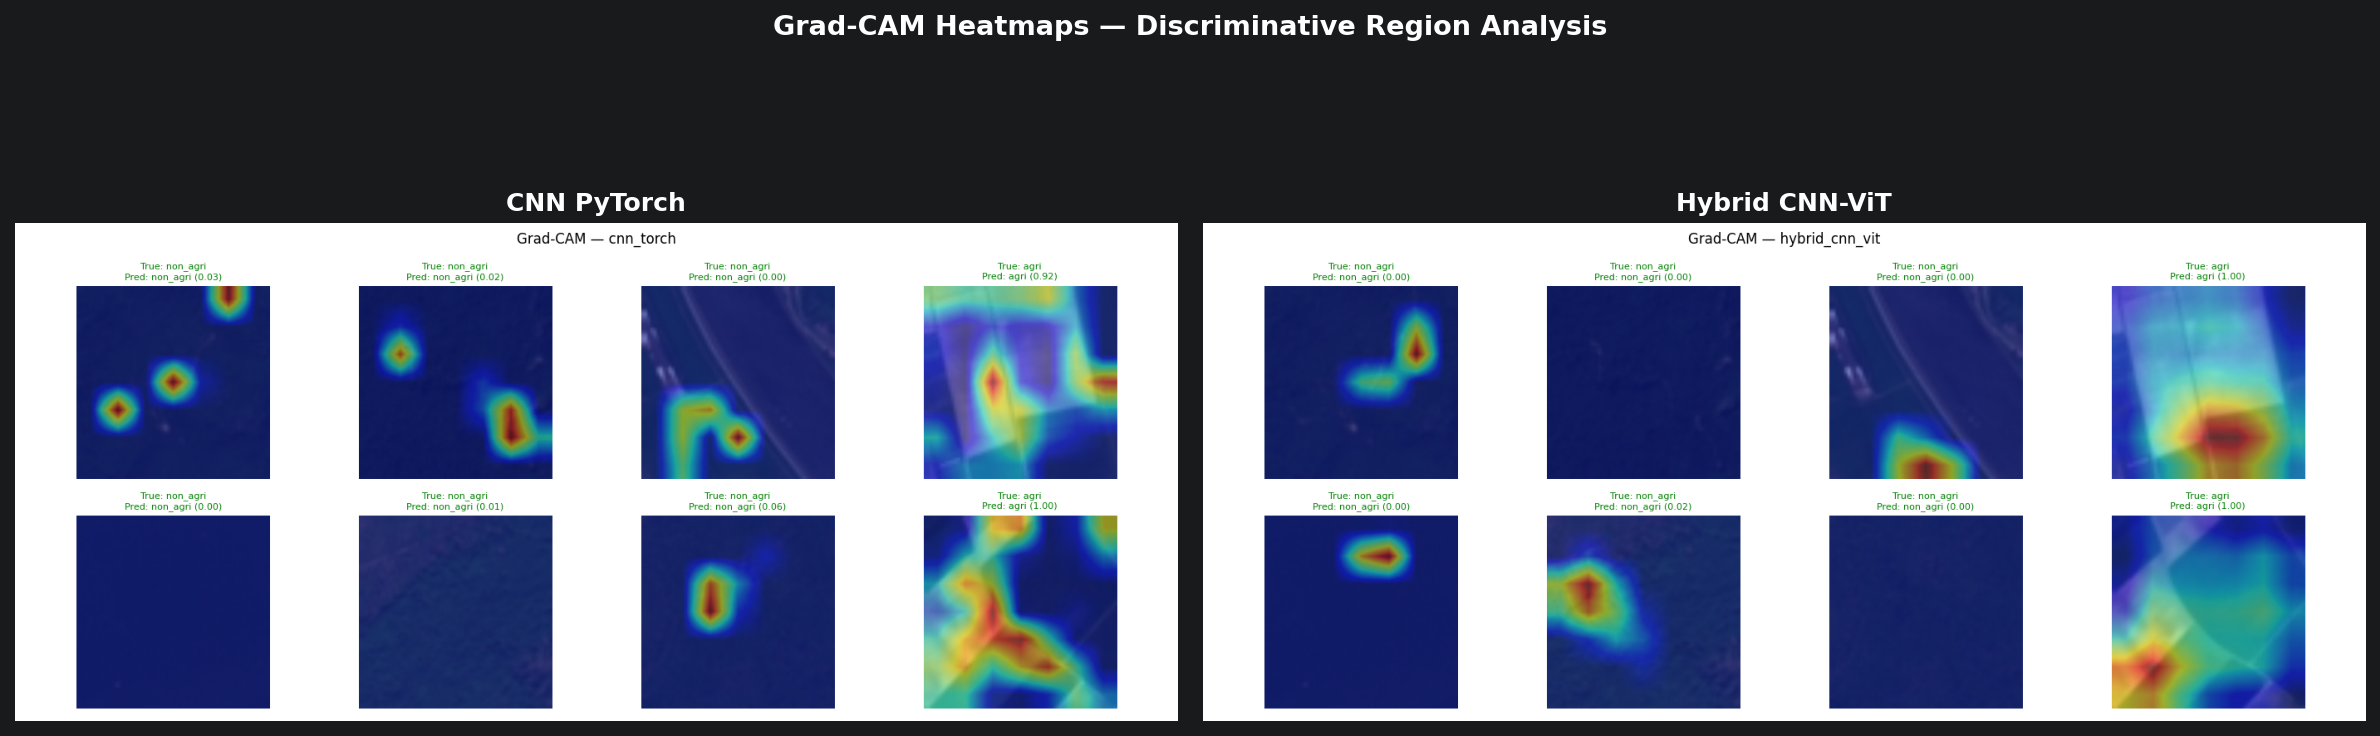

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, fname) in zip(axes, [
    ('CNN PyTorch',    'cnn_torch_gradcam.png'),
    ('Hybrid CNN-ViT', 'hybrid_cnn_vit_gradcam.png'),
]):
    ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, fname)))
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Grad-CAM Heatmaps — Discriminative Region Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Both models focus on semantically meaningful regions. For agricultural tiles, activations concentrate on crop row patterns and field textures. For non-agricultural tiles, the models attend to structural features such as road networks (Industrial/Residential) and water surface reflectance (River/SeaLake). The Hybrid model shows broader, more distributed attention compared to the CNN — consistent with the Transformer's global spatial reasoning over CNN-extracted local feature tokens.

---
## 6. Key Findings & Reflections

In [9]:
print('=' * 62)
print('  PROJECT SUMMARY — AgriVision')
print('=' * 62)
print(f'  Dataset  : EuroSAT RGB  |  11,000 images  |  64×64 → 224×224')
print(f'  Task     : Binary classification (agri / non-agri)')
print(f'  Platform : Kaggle (T4 GPU)  |  ~2.5 hours total training time')
print()
for r in results:
    best = ' ← best F1' if r['Model'] == 'ViT Fine-Tuned' else ''
    print(f"  {r['Model']:<18}  "
          f"Acc={r['Accuracy']:.4f}  "
          f"F1={r['F1']:.4f}  "
          f"AUC={r['ROC-AUC']:.4f}  "
          f"{r['Params (M)']:.1f}M params"
          f"{best}")
print()
print('  Framework comparison (same architecture):')
print('    PyTorch F1=0.9617  |  Keras F1=0.9649  |  Δ=0.003 (negligible)')
print('=' * 62)

  PROJECT SUMMARY — AgriVision
  Dataset  : EuroSAT RGB  |  11,000 images  |  64×64 → 224×224
  Task     : Binary classification (agri / non-agri)
  Platform : Kaggle (T4 GPU)  |  ~2.5 hours total training time

  CNN PyTorch         Acc=0.9618  F1=0.9617  AUC=0.9947  1.6M params
  CNN Keras           Acc=0.9651  F1=0.9649  AUC=0.9950  1.6M params
  ViT Fine-Tuned      Acc=0.9921  F1=0.9922  AUC=0.9998  85.8M params ← best F1
  Hybrid CNN-ViT      Acc=0.9855  F1=0.9855  AUC=0.9992  27.4M params

  Framework comparison (same architecture):
    PyTorch F1=0.9617  |  Keras F1=0.9649  |  Δ=0.003 (negligible)


### CNN Baseline
Both CNN implementations exceeded 96% accuracy. The near-identical results between PyTorch and Keras (ΔF1=0.003) confirm the architecture drives performance, not the framework. PyTorch offered more control over the training loop; Keras callbacks (`ReduceLROnPlateau`, early stopping) produced clean convergence with less code.

### Vision Transformer
The ViT achieved **99.2% F1 and 0.9998 AUC** — a 2.7 percentage point improvement over the CNN baseline. The two-phase fine-tuning strategy was essential: freezing the backbone for 5 epochs prevented pretrained ImageNet weights from being corrupted early in training. The ViT's global self-attention is well suited to satellite imagery where long-range spatial relationships between field boundaries carry discriminative signal. The main tradeoff is 85.8M parameters and 14ms inference latency vs 0.7ms for the CNN.

### Hybrid CNN-ViT
The hybrid achieved **98.5% F1 and 0.9992 AUC** with only 27.4M parameters and 3.4ms inference — a strong efficiency tradeoff sitting between the CNN and standalone ViT. Training was unstable (loss spikes at epochs 3–8, early stopping at epoch 8), likely due to the learning rate being too aggressive for joint CNN-Transformer optimisation. A lower initial LR (`1e-4`) and longer warmup would stabilise training and likely close the gap to the ViT.

### Framework Comparison Summary

| Aspect | PyTorch | Keras |
|---|---|---|
| Custom architectures | Native (`nn.Module`) | Functional API |
| ViT / timm ecosystem | First-class | Limited |
| Training loop control | Full manual | Callback-driven |
| Prototyping speed | Slower | Faster |
| Best for this project | Parts 3–4 (ViT, Hybrid) | Part 2 (CNN baseline) |

